# 🏠 Stage 3: House Price Predictor
### ML Roadmap — Linear Regression Project


## Step 0: Install & Import Libraries

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — the core ML library
from sklearn.model_selection   import train_test_split, cross_val_score, KFold
from sklearn.linear_model      import LinearRegression, Ridge, Lasso
from sklearn.preprocessing     import StandardScaler, OneHotEncoder
from sklearn.compose           import ColumnTransformer
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute            import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42 
np.random.seed(SEED)

print('✅ All libraries imported')
import sklearn; print(f'   Scikit-learn: {sklearn.__version__}')

✅ All libraries imported
   Scikit-learn: 1.8.0


---
## Step 1: Generate & Load the Dataset
1,460 Tamil Nadu properties across 10 cities — same row count as the famous Ames Housing dataset.

In [2]:
def generate_house_dataset(n=1460, seed=42):
    """
    Generate a realistic Tamil Nadu house price dataset.
    Price is determined by:
      base_price = sqft × rate + amenities − penalties
      final      = base × quality_multiplier × city_multiplier + furnishing_bonus + noise
    """
    np.random.seed(seed)

    cities  = ['Chennai','Coimbatore','Madurai','Trichy','Salem',
                'Erode','Vellore','Tirunelveli','Hosur','Thanjavur']
    areas   = ['Anna Nagar','T Nagar','Adyar','Velachery','Tambaram','Porur',
                'Chromepet','Perambur','Sholinganallur','Pallavaram',
                'RS Puram','Gandhipuram','Saibaba Colony','Singanallur',
                'Peelamedu','KK Nagar','Alwarpet','Nungambakkam','Mylapore',
                'Besant Nagar','Kodambakkam','Ashok Nagar','Ramanathapuram']
    quality  = ['Poor','Fair','Average','Good','Excellent']
    furnished= ['Fully','Semi','Unfurnished']

    city_arr  = np.random.choice(cities, n, p=[0.30,0.20,0.10,0.08,0.07,0.06,0.05,0.05,0.05,0.04])
    area_arr  = np.random.choice(areas, n)
    qual_arr  = np.random.choice(quality,    n, p=[0.05,0.15,0.35,0.30,0.15])
    furn_arr  = np.random.choice(furnished,  n, p=[0.25,0.40,0.35])
    year_built= np.random.randint(1985, 2023, n)
    sqft      = np.clip(np.random.normal(1450, 450, n), 400, 5000).round(0).astype(int)
    bedrooms  = np.random.choice([1,2,3,4,5], n, p=[0.05,0.25,0.45,0.20,0.05])
    bathrooms = np.clip(bedrooms - np.random.randint(0,2,n), 1, 5)
    floors    = np.random.choice([1,2,3], n, p=[0.40,0.45,0.15])
    garage    = np.random.choice([0,1,2], n, p=[0.30,0.55,0.15])
    pool      = np.random.choice([0,1],   n, p=[0.85,0.15])
    garden    = np.random.choice([0,1],   n, p=[0.60,0.40])
    age       = 2024 - year_built

    school_dist   = np.round(np.clip(np.random.exponential(2.5, n), 0.2, 15), 2)
    hospital_dist = np.round(np.clip(np.random.exponential(3.0, n), 0.3, 20), 2)
    metro_dist    = np.round(np.clip(np.random.exponential(4.0, n), 0.5, 25), 2)
    crime_rate    = np.round(np.clip(np.random.normal(4.5, 2.0, n), 0.5, 10), 2)

    qual_map = {'Poor':0.70,'Fair':0.85,'Average':1.00,'Good':1.20,'Excellent':1.45}
    city_map = {'Chennai':1.35,'Coimbatore':1.10,'Madurai':0.90,'Trichy':0.88,
                'Salem':0.82,'Erode':0.80,'Vellore':0.85,'Tirunelveli':0.78,
                'Hosur':1.05,'Thanjavur':0.75}

    base = (sqft*3800 + bedrooms*120000 + bathrooms*80000 + garage*150000
            + pool*500000 + garden*80000 + floors*50000
            - age*8000 - school_dist*25000 - metro_dist*20000 - crime_rate*30000)

    q_mult   = np.array([qual_map[q] for q in qual_arr])
    c_mult   = np.array([city_map[c] for c in city_arr])
    furn_add = np.where(np.array(furn_arr)=='Fully', 300000,
                np.where(np.array(furn_arr)=='Semi', 150000, 0))

    price = base * q_mult * c_mult + furn_add
    price = np.clip(price + np.random.normal(0, 200000, n), 800000, 25000000)
    price = (price / 100000).round(2)  # → Lakhs

    df = pd.DataFrame({
        'house_id':         [f'TN{3000+i}' for i in range(n)],
        'city':             city_arr,
        'area_name':        area_arr,
        'sqft':             sqft,
        'bedrooms':         bedrooms,
        'bathrooms':        bathrooms,
        'floors':           floors,
        'garage_cars':      garage,
        'has_pool':         pool,
        'has_garden':       garden,
        'furnished':        furn_arr,
        'quality':          qual_arr,
        'year_built':       year_built,
        'age_years':        age,
        'school_dist_km':   school_dist,
        'hospital_dist_km': hospital_dist,
        'metro_dist_km':    metro_dist,
        'crime_rate':       crime_rate,
        'price_lakhs':      price,
    })

    # Inject realistic 4% missing values
    for col in ['sqft','school_dist_km','crime_rate','garage_cars']:
        idx = np.random.choice(df.index, size=int(n*0.04), replace=False)
        df.loc[idx, col] = np.nan

    return df


# Generate & save
df = generate_house_dataset(n=1460)
# df.to_csv('house_prices.csv', index=False)

# ── OR load if you already have the CSV ──
df = pd.read_csv('house_prices.csv')

print(f'✅ Dataset loaded: {df.shape[0]:,} properties × {df.shape[1]} features')
print(f'   Price range: ₹{df["price_lakhs"].min():.1f}L  →  ₹{df["price_lakhs"].max():.1f}L')
print(f'   Avg price  : ₹{df["price_lakhs"].mean():.1f}L')
df.head()

✅ Dataset loaded: 1,460 properties × 19 features
   Price range: ₹11.9L  →  ₹199.6L
   Avg price  : ₹68.7L


,house_id,city,area_name,sqft,bedrooms,bathrooms,floors,garage_cars,has_pool,has_garden,furnished,quality,year_built,age_years,school_dist_km,hospital_dist_km,metro_dist_km,crime_rate,price_lakhs
0,TN3000,Coimbatore,Kodambakkam,681.00,3,3,1,2.00,0,0,Semi,Good,2016,8,1.15,4.78,2.44,4.95,44.37
1,TN3001,Hosur,KK Nagar,2003.00,2,1,1,0.00,1,0,Unfurnished,Good,2006,18,2.24,5.54,0.50,4.14,104.51
2,TN3002,Salem,Tambaram,1497.00,3,2,1,2.00,0,0,Fully,Average,2002,22,1.08,1.54,2.34,6.81,56.17
3,TN3003,Madurai,Sholinganallur,2075.00,3,3,2,1.00,0,0,Semi,Average,2016,8,0.60,1.69,1.84,3.81,77.41
4,TN3004,Chennai,T Nagar,1776.00,5,5,1,1.00,0,0,Unfurnished,Poor,2011,13,0.31,0.48,4.43,2.53,70.51


---
## Step 2: Data Overview & Missing Values

In [3]:
print('━'*55)
print('           DATASET OVERVIEW')
print('━'*55)
print(f'  Rows        : {df.shape[0]:,}')
print(f'  Columns     : {df.shape[1]}')
print(f'  Memory      : {df.memory_usage(deep=True).sum()/1024:.1f} KB')

print('\n📋 Dtypes & Missing Values:')
audit = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().sum()/len(df)*100).round(1),
    'unique' : df.nunique()
})
print(audit.to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rows        : 1,460
  Columns     : 19
  Memory      : 559.6 KB

📋 Dtypes & Missing Values:
                    dtype  missing  missing%  unique
house_id              str        0      0.00    1460
city                  str        0      0.00      10
area_name             str        0      0.00      23
sqft              float64       58      4.00     946
bedrooms            int64        0      0.00       5
bathrooms           int64        0      0.00       5
floors              int64        0      0.00       3
garage_cars       float64       58      4.00       3
has_pool            int64        0      0.00       2
has_garden          int64        0      0.00       2
furnished             str        0      0.00       3
quality               str        0      0.00       5
year_built          int64        0      0.00      38
age_years           int6

In [ ]:
# Numeric summary statistics
print('📊 Numeric Summary:')
num_cols = df.select_dtypes(include='number').columns
df[num_cols].describe().round(2)

📊 Numeric Summary:


,sqft,bedrooms,bathrooms,floors,garage_cars,has_pool,has_garden,year_built,age_years,school_dist_km,hospital_dist_km,metro_dist_km,crime_rate,price_lakhs
count,1402.00,1460.00,1460.00,1460.00,1402.00,1460.00,1460.00,1460.00,1460.00,1402.00,1460.00,1460.00,1402.00,1460.00
mean,1426.65,2.92,2.43,1.77,0.84,0.16,0.39,2003.63,20.37,2.51,3.22,4.10,4.64,68.73
std,462.76,0.88,0.97,0.72,0.66,0.36,0.49,10.97,10.97,2.37,3.18,4.01,1.93,29.68
min,400.00,1.00,1.00,1.00,0.00,0.00,0.00,1985.00,2.00,0.20,0.30,0.50,0.50,11.93
25%,1109.50,2.00,2.00,1.00,0.00,0.00,0.00,1994.00,11.00,0.81,0.94,1.27,3.35,47.62
50%,1425.50,3.00,2.00,2.00,1.00,0.00,0.00,2004.00,20.00,1.85,2.25,2.78,4.62,63.35
75%,1739.00,3.00,3.00,2.00,1.00,0.00,1.00,2013.00,30.00,3.40,4.36,5.58,5.96,85.30
max,2908.00,5.00,5.00,3.00,2.00,1.00,1.00,2022.00,39.00,15.00,20.00,25.00,10.00,199.61


---
## Step 3: Exploratory Data Analysis (EDA)


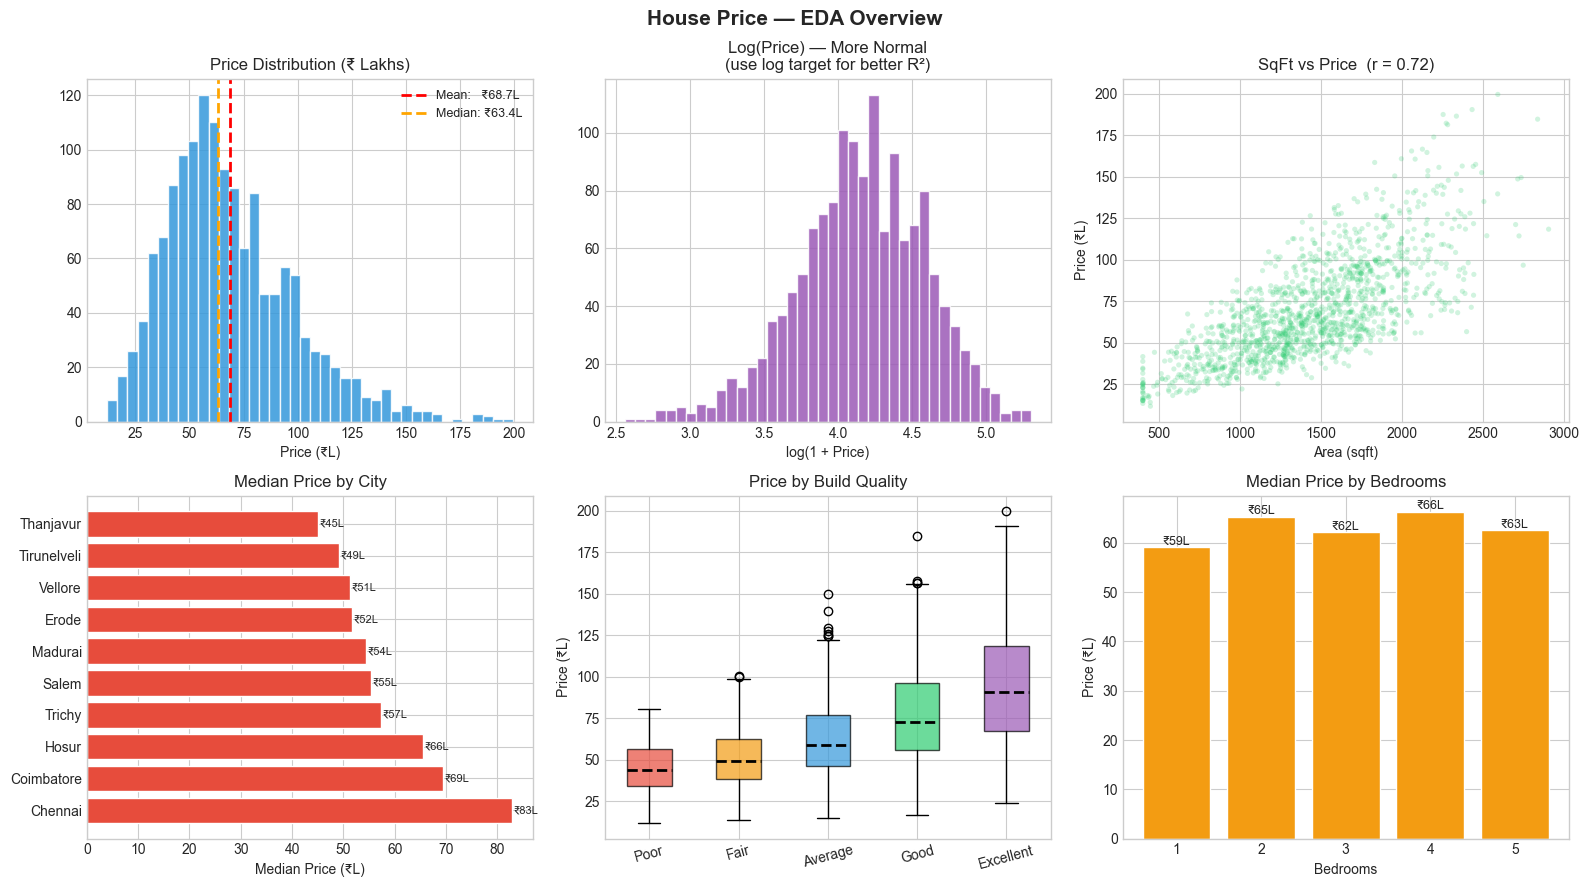

💾 Saved: hp_01_eda_overview.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('House Price — EDA Overview', fontsize=15, fontweight='bold')

# 1. Price distribution
axes[0,0].hist(df['price_lakhs'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['price_lakhs'].mean(),   color='red',    ls='--', lw=2, label=f'Mean:   ₹{df["price_lakhs"].mean():.1f}L')
axes[0,0].axvline(df['price_lakhs'].median(), color='orange', ls='--', lw=2, label=f'Median: ₹{df["price_lakhs"].median():.1f}L')
axes[0,0].set_title('Price Distribution (₹ Lakhs)')
axes[0,0].set_xlabel('Price (₹L)'); axes[0,0].legend(fontsize=9)

# 2. Log-price (normalised — better for regression)
axes[0,1].hist(np.log1p(df['price_lakhs']), bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Log(Price) — More Normal\n(use log target for better R²)')
axes[0,1].set_xlabel('log(1 + Price)')

# 3. SqFt vs Price (and correlation)
axes[0,2].scatter(df['sqft'], df['price_lakhs'], alpha=0.22, s=14, c='#2ecc71', edgecolors='none')
corr_sq = df['sqft'].corr(df['price_lakhs'])
axes[0,2].set_title(f'SqFt vs Price  (r = {corr_sq:.2f})')
axes[0,2].set_xlabel('Area (sqft)'); axes[0,2].set_ylabel('Price (₹L)')

# 4. Price by city

city_med = df.groupby('city')['price_lakhs'].median().sort_values(ascending=False)
axes[1,0].barh(city_med.index, city_med.values, color='#e74c3c', edgecolor='white')
axes[1,0].set_title('Median Price by City')
axes[1,0].set_xlabel('Median Price (₹L)')
for i,v in enumerate(city_med.values):
    axes[1,0].text(v+0.3, i, f'₹{v:.0f}L', va='center', fontsize=8)

qual_order = ['Poor','Fair','Average','Good','Excellent']
qual_data  = [df[df['quality']==q]['price_lakhs'].values for q in qual_order]
# Boxplot: 👉 Data distribution காட்டும் chart.
# It shows: Median ,Quartiles ,Spread ,Outliers
bp = axes[1,1].boxplot(qual_data, labels=qual_order, patch_artist=True,
                        medianprops=dict(color='black',ls='--', linewidth=2))
colors_q = ['#e74c3c','#f39c12','#3498db','#2ecc71','#9b59b6']
# ஒவ்வொரு box-க்கும் corresponding color assign செய்கிறது.
for patch, c in zip(bp['boxes'], colors_q):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,1].set_title('Price by Build Quality')
axes[1,1].set_ylabel('Price (₹L)')
axes[1,1].tick_params(axis='x', rotation=15)

# 6. Price by bedrooms - Bedroom count அடிப்படையில் median house price calculate செய்கிறது.
bed_med = df.groupby('bedrooms')['price_lakhs'].median()
axes[1,2].bar(bed_med.index, bed_med.values, color='#f39c12', edgecolor='white')
axes[1,2].set_title('Median Price by Bedrooms')
axes[1,2].set_xlabel('Bedrooms'); axes[1,2].set_ylabel('Price (₹L)')
for k,v in bed_med.items():
    axes[1,2].text(k, v+0.5, f'₹{v:.0f}L', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('hp_01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hp_01_eda_overview.png')

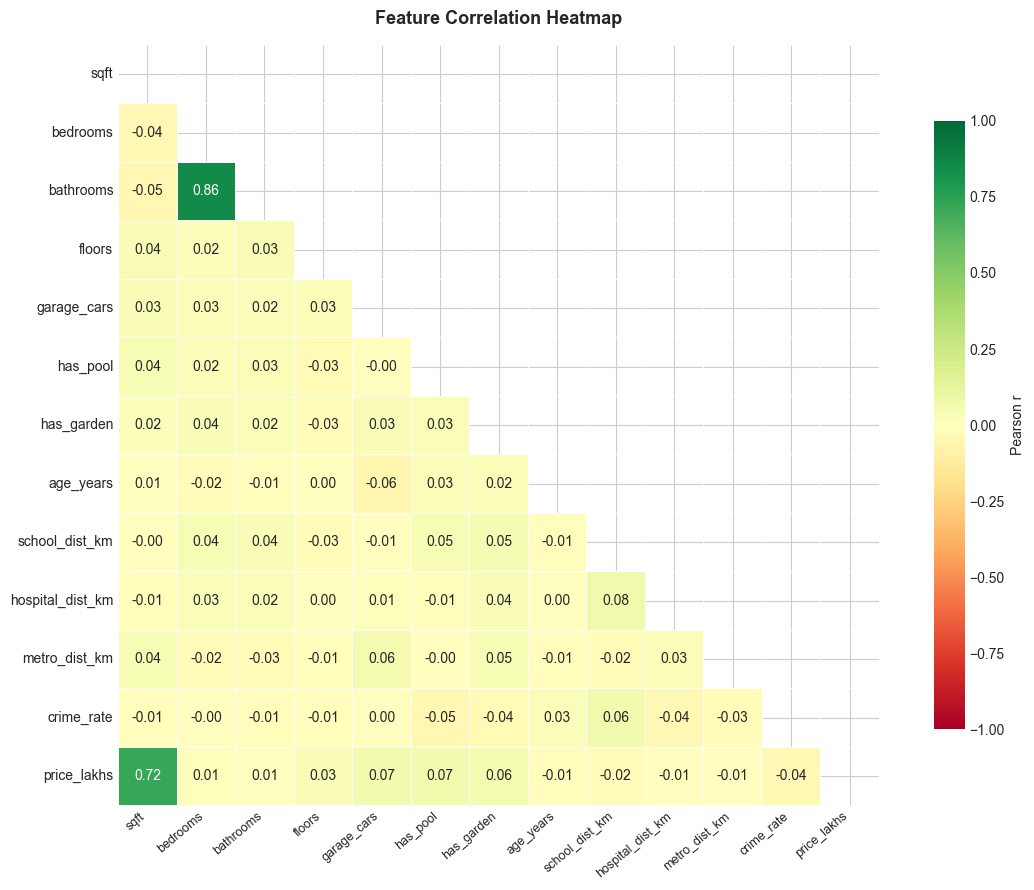

💾 Saved: hp_02_correlation.png

🔗 Feature correlation with price_lakhs:
sqft                0.72
has_pool            0.07
garage_cars         0.07
has_garden          0.06
crime_rate         -0.04
floors              0.03
school_dist_km     -0.02
bedrooms            0.01
age_years          -0.01
bathrooms           0.01
hospital_dist_km   -0.01
metro_dist_km      -0.01


In [6]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
num_cols = ['sqft','bedrooms','bathrooms','floors','garage_cars','has_pool','has_garden',
            'age_years','school_dist_km','hospital_dist_km','metro_dist_km','crime_rate','price_lakhs']
corr = df[num_cols].corr().round(3)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            square=True, cbar_kws={'label':'Pearson r','shrink':0.8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('hp_02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hp_02_correlation.png')

# Print top correlations with price
price_corr = corr['price_lakhs'].drop('price_lakhs').sort_values(key=abs, ascending=False)
print('\n🔗 Feature correlation with price_lakhs:')
print(price_corr.to_string())

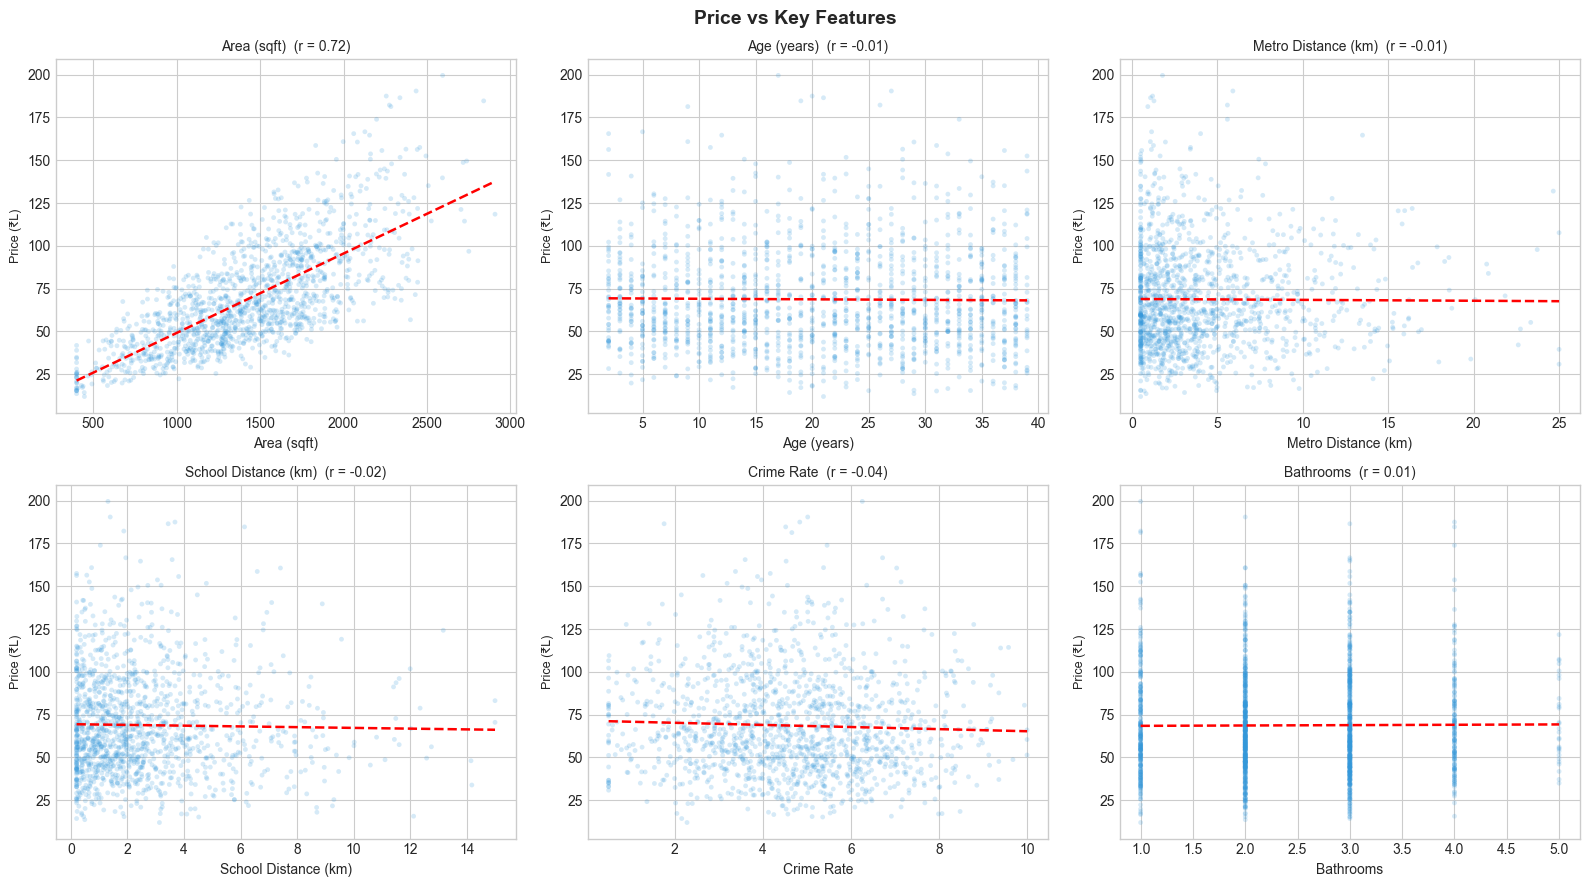

💾 Saved: hp_06_scatter_matrix.png


In [7]:
# ── Scatter matrix — price vs key features ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Price vs Key Features', fontsize=14, fontweight='bold')

key_feats = ['sqft','age_years','metro_dist_km','school_dist_km','crime_rate','bathrooms']
xlabels   = ['Area (sqft)','Age (years)','Metro Distance (km)','School Distance (km)','Crime Rate','Bathrooms']

for ax, feat, xl in zip(axes.flatten(), key_feats, xlabels):
    corr_v = df[feat].corr(df['price_lakhs'])
    ax.scatter(df[feat], df['price_lakhs'], alpha=0.2, s=12, c='#3498db', edgecolors='none')
    ax.set_xlabel(xl, fontsize=10)
    ax.set_ylabel('Price (₹L)', fontsize=9)
    ax.set_title(f'{xl}  (r = {corr_v:.2f})', fontsize=10)
    # Trend line
    clean = df[[feat,'price_lakhs']].dropna()
    z = np.polyfit(clean[feat], clean['price_lakhs'], 1)
    p = np.poly1d(z)
    xs = np.linspace(clean[feat].min(), clean[feat].max(), 100)
    ax.plot(xs, p(xs), 'r--', lw=1.8)

plt.tight_layout()
plt.savefig('hp_06_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hp_06_scatter_matrix.png')

---
## Step 4: Feature Engineering

In [ ]:
df_model = df.copy()

# ── New features ─────────────────────────────────────────────────────────────
df_model['price_per_sqft']   = (df_model['price_lakhs'] * 100000 / df_model['sqft'].fillna(df_model['sqft'].median())).round(0)
df_model['total_rooms']      = df_model['bedrooms'] + df_model['bathrooms']
df_model['amenity_score']    = df_model['has_pool'] + df_model['has_garden'] + df_model['garage_cars']
df_model['is_new']           = (df_model['age_years'] <= 5).astype(int)     
df_model['is_premium']       = (df_model['quality'].isin(['Good','Excellent'])).astype(int)
df_model['proximity_score']  = -(df_model['school_dist_km'].fillna(2.5)
                                + df_model['metro_dist_km']
                                + df_model['hospital_dist_km']) / 3  # closer = higher score
df_model['log_sqft']         = np.log1p(df_model['sqft'])
df_model['sqft_per_bedroom'] = (df_model['sqft'] / df_model['bedrooms'].replace(0,1)).round(0)

new_feats = ['price_per_sqft','total_rooms','amenity_score','is_new','is_premium',
             'proximity_score','log_sqft','sqft_per_bedroom']
print('✅ New features created:')
for f in new_feats:
    print(f'   {f:<22} — sample: {df_model[f].dropna().head(3).tolist()}')

✅ New features created:
   price_per_sqft         — sample: [6515.0, 5218.0, 3752.0]
   total_rooms            — sample: [6, 3, 5]
   amenity_score          — sample: [2.0, 1.0, 2.0]
   is_new                 — sample: [0, 0, 0]
   is_premium             — sample: [1, 1, 0]
   proximity_score        — sample: [-2.7900000000000005, -2.7600000000000002, -1.6533333333333333]
   log_sqft               — sample: [6.525029657843462, 7.602900462204755, 7.311886164077165]
   sqft_per_bedroom       — sample: [227.0, 1002.0, 499.0]


---
## Step 5: Preprocessing Pipeline



In [ ]:
# ── Define features ─
num_feats = [
    'sqft','bedrooms','bathrooms','floors','garage_cars','has_pool','has_garden',
    'age_years','school_dist_km','hospital_dist_km','metro_dist_km','crime_rate',
    'total_rooms','amenity_score','is_new','is_premium','proximity_score',
    'log_sqft','sqft_per_bedroom'
]
# Categorical Feature
cat_feats = ['city','furnished','quality']
TARGET    = 'price_lakhs'

X = df_model[num_feats + cat_feats] 
y = df_model[TARGET] # Dependent Variable - output

# ── Train / Test split (80/20) ───────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'✅ Train set : {X_train.shape[0]:,} rows')
print(f'   Test set  : {X_test.shape[0]:,} rows')
print(f'   Features  : {X.shape[1]} ({len(num_feats)} numeric + {len(cat_feats)} categorical)')



✅ Train set : 1,168 rows
   Test set  : 292 rows
   Features  : 22 (19 numeric + 3 categorical)


In [ ]:
# ── Build the preprocessing + model pipelines ─────────────────────────────────

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')), 
    ('scale',  StandardScaler()) 
])

# Categorical: impute with mode → one-hot encode
cat_pipe = Pipeline([

    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # handle_unknown='ignore'))


])
.
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_feats),
    ('cat', cat_pipe, cat_feats)
])

# Three models to compare
models = {
    'Linear Regression' : Pipeline([('pre', preprocessor), ('model', LinearRegression())]), # Best-fit line மூலம் prediction.
    'Ridge  (α=10)'     : Pipeline([('pre', preprocessor), ('model', Ridge(alpha=10))]), # L2 regularization - 👉 model-ஐ overfitting-இல் இருந்து காப்பாற்றும். α=10 means stronger regularization.  Keeps all features
    'Lasso  (α=0.1)'    : Pipeline([('pre', preprocessor), ('model', Lasso(alpha=0.1, max_iter=5000))]), # L1 regularization - 👉 model-ஐ overfitting-இல் இருந்து காப்பாற்றும். α=0.1 means moderate regularization. max_iter=5000 - convergence ensure செய்யும். Removes useless features
}

print('✅ Pipelines built:')
for name in models:
    print(f'   {name}')
print()
print('  Pipeline steps: Impute → Scale → OneHotEncode → Fit Model')
print('  Data leakage is PREVENTED — scaler is fit only on train set!')

✅ Pipelines built:
   Linear Regression
   Ridge  (α=10)
   Lasso  (α=0.1)

  Pipeline steps: Impute → Scale → OneHotEncode → Fit Model
  Data leakage is PREVENTED — scaler is fit only on train set!


---
## Step 6: Train & Evaluate All Models

In [ ]:

results     = {}
predictions = {}

print('━'*70)
print(f'  {"Model":<22}  {"RMSE (₹L)":>10}  {"MAE (₹L)":>10}  {"R²":>8}  {"CV R²":>8}')
print('━'*70)

for name, pipe in models.items():
    # Train
    pipe.fit(X_train, y_train)

    # Predict
    pred = pipe.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    cv   = cross_val_score(pipe, X, y, cv=5, scoring='r2').mean()

    results[name]     = {'RMSE':rmse,'MAE':mae,'R2':r2,'CV_R2':cv}
    predictions[name] = pred

    flag = '⭐' if r2 == max([results[n]['R2'] for n in results], default=0) else '  '
    print(f'{flag}{name:<22}  {rmse:>10.2f}  {mae:>10.2f}  {r2:>8.4f}  {cv:>8.4f}')

print('━'*70)
best_name = max(results, key=lambda k: results[k]['R2'])
best_pred = predictions[best_name]
print(f'\n🏆 Best model: {best_name}  (R² = {results[best_name]["R2"]:.4f})')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model                    RMSE (₹L)    MAE (₹L)        R²     CV R²
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⭐Linear Regression             7.98        5.34    0.9248    0.9315
  Ridge  (α=10)                 8.14        5.44    0.9218    0.9303
  Lasso  (α=0.1)                8.14        5.54    0.9218    0.9297
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 Best model: Linear Regression  (R² = 0.9248)


---
## Step 7: Visualise Model Performance

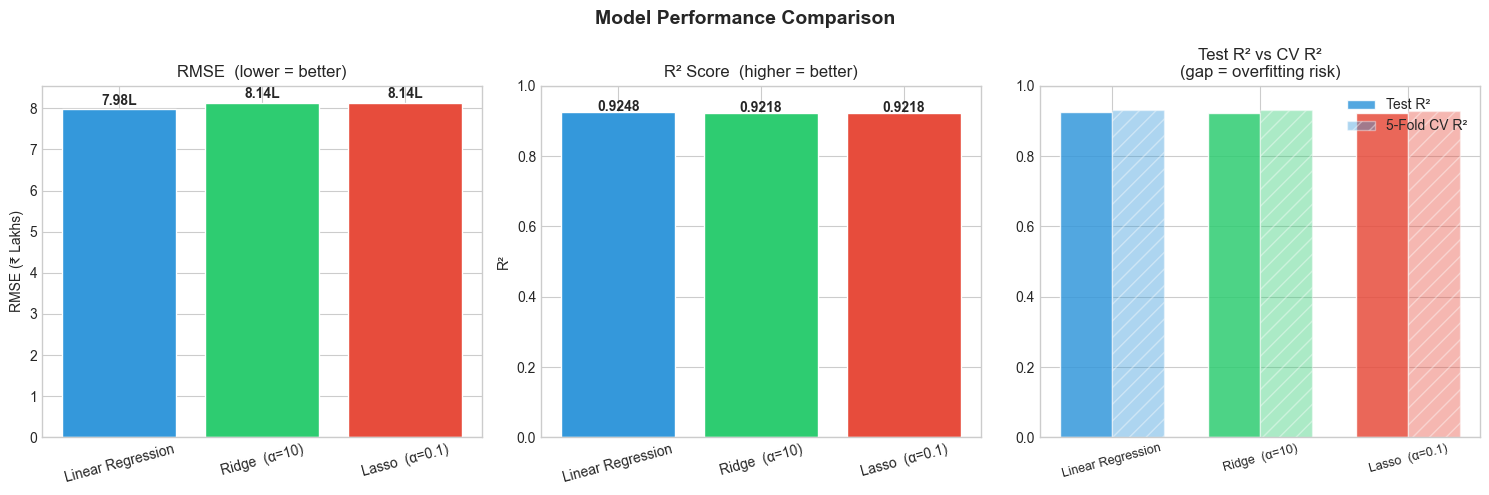

💾 Saved: hp_03_model_comparison.png


In [ ]:
# ── Chart: Model comparison bar charts 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

names = list(results.keys())
rmses = [results[n]['RMSE']  for n in names]  
r2s   = [results[n]['R2']    for n in names] 
cvs   = [results[n]['CV_R2'] for n in names] 
cols  = ['#3498db','#2ecc71','#e74c3c']

# RMSE - Prediction error குறைவு, Better model
axes[0].bar(names, rmses, color=cols, edgecolor='white')
axes[0].set_title('RMSE  (lower = better)')
axes[0].set_ylabel('RMSE (₹ Lakhs)')
for i,v in enumerate(rmses): axes[0].text(i,v+0.1,f'{v:.2f}L',ha='center',fontweight='bold',fontsize=10)
axes[0].tick_params(axis='x',rotation=15)

axes[1].bar(names, r2s, color=cols, edgecolor='white')
axes[1].set_title('R² Score  (higher = better)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
for i,v in enumerate(r2s): axes[1].text(i,v+0.005,f'{v:.4f}',ha='center',fontweight='bold',fontsize=10)
axes[1].tick_params(axis='x',rotation=15)

x_pos = np.arange(len(names)); w=0.35
axes[2].bar(x_pos-w/2, r2s, w, label='Test R²',    color=cols, edgecolor='white', alpha=0.85)
axes[2].bar(x_pos+w/2, cvs, w, label='5-Fold CV R²', color=cols, edgecolor='white', alpha=0.4, hatch='//')
axes[2].set_title('Test R² vs CV R²\n(gap = overfitting risk)')
axes[2].set_xticks(x_pos); axes[2].set_xticklabels(names, rotation=15, fontsize=9)
axes[2].set_ylim(0,1); axes[2].legend()


plt.tight_layout()
plt.savefig('hp_03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hp_03_model_comparison.png')

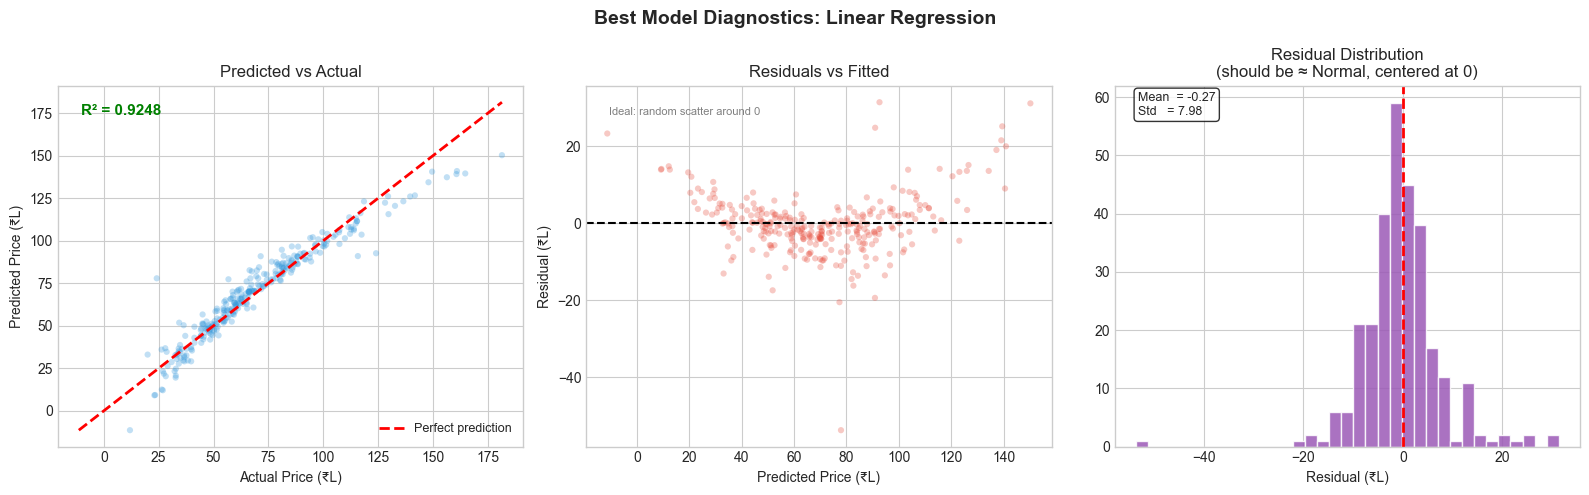

💾 Saved: hp_04_diagnostics.png


In [ ]:


residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Best Model Diagnostics: {best_name}', fontsize=14, fontweight='bold')

# Predicted vs Actual
lo = min(y_test.min(), best_pred.min())
hi = max(y_test.max(), best_pred.max())
axes[0].scatter(y_test, best_pred, alpha=0.3, s=20, c='#3498db', edgecolors='none')
axes[0].plot([lo,hi],[lo,hi],'r--', lw=2, label='Perfect prediction')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual Price (₹L)')
axes[0].set_ylabel('Predicted Price (₹L)')
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.92, f'R² = {results[best_name]["R2"]:.4f}',
             transform=axes[0].transAxes, fontsize=11, fontweight='bold', color='green')

# Residuals vs Fitted
axes[1].scatter(best_pred, residuals, alpha=0.3, s=20, c='#e74c3c', edgecolors='none')
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Residuals vs Fitted')
axes[1].set_xlabel('Predicted Price (₹L)')
axes[1].set_ylabel('Residual (₹L)')
axes[1].text(0.05,0.92,f'Ideal: random scatter around 0',
             transform=axes[1].transAxes, fontsize=8, color='grey')

# Residual distribution
axes[2].hist(residuals, bins=35, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', lw=2, linestyle='--')
axes[2].set_title('Residual Distribution\n(should be ≈ Normal, centered at 0)')
axes[2].set_xlabel('Residual (₹L)')
axes[2].text(0.05,0.92,
             f'Mean  = {residuals.mean():.2f}\nStd   = {residuals.std():.2f}',
             transform=axes[2].transAxes, fontsize=9,
             bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))

plt.tight_layout()
plt.savefig('hp_04_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hp_04_diagnostics.png')

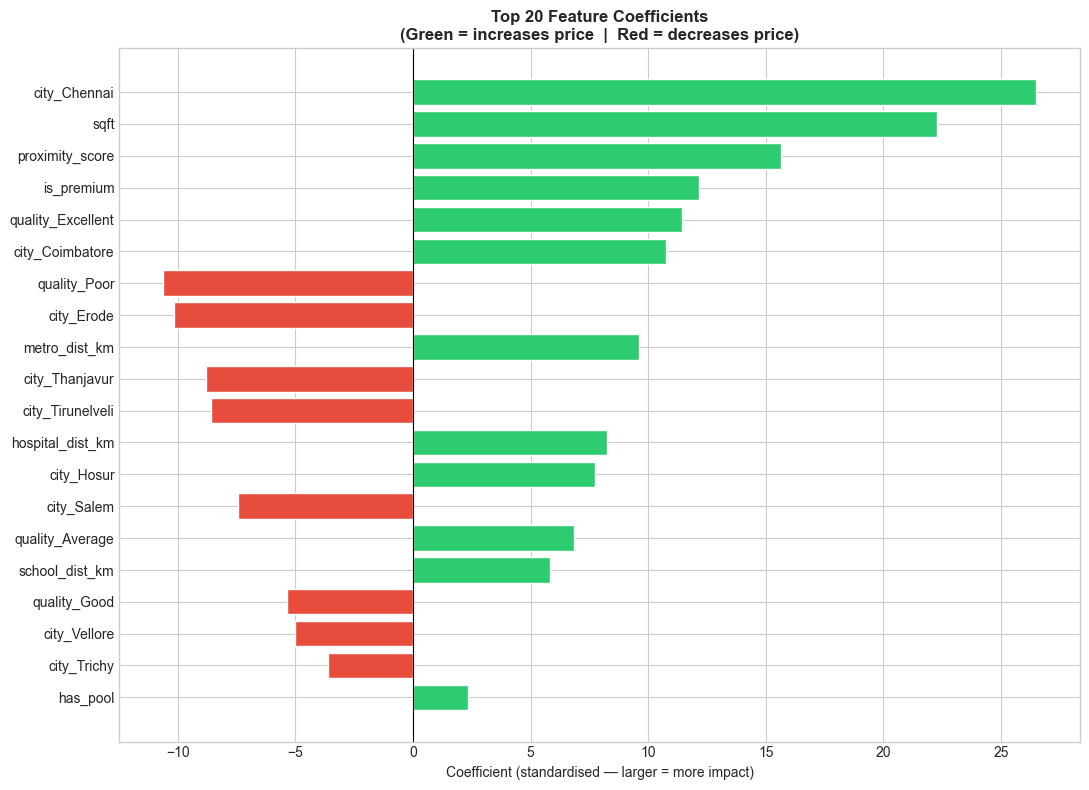

💾 Saved: hp_05_feature_importance.png


In [ ]:


best_pipe = models[best_name]
lr_model  = best_pipe.named_steps['model']
ohe_cols  = (best_pipe.named_steps['pre']
             .transformers_[1][1]
             .named_steps['ohe']
             .get_feature_names_out(cat_feats))
all_feats = num_feats + list(ohe_cols)

feat_imp = (pd.Series(lr_model.coef_, index=all_feats)
            .sort_values(key=abs, ascending=False)
            .head(20))

bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in feat_imp.values]

plt.figure(figsize=(11, 8))
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
         color=bar_colors[::-1], edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Top 20 Feature Coefficients\n(Green = increases price  |  Red = decreases price)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient (standardised — larger = more impact)')
plt.tight_layout()
plt.savefig('hp_05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hp_05_feature_importance.png')

---
## Step 8: Make Real Predictions

In [ ]:
def predict_house_price(city, sqft, bedrooms, bathrooms, quality,
                        furnished='Semi', age_years=10, floors=2,
                        garage_cars=1, has_pool=0, has_garden=1,
                        school_dist_km=1.5, hospital_dist_km=2.0,
                        metro_dist_km=3.0, crime_rate=4.0,
                        model_name=None):
    """
    User கொடுக்கும் house details அடிப்படையில்
Machine Learning model house price predict செய்கிறது.

    Predict house price in ₹ Lakhs for a given property.
    
    Example:
        predict_house_price('Chennai', 2000, 3, 2, 'Good')
    """

    # Best trained model 
    if model_name is None:
        model_name = best_name

    # Engineered features 
    total_rooms      = bedrooms + bathrooms
    amenity_score    = has_pool + has_garden + garage_cars
    is_new           = int(age_years <= 5)
    is_premium       = int(quality in ['Good','Excellent'])
    proximity_score  = -(school_dist_km + metro_dist_km + hospital_dist_km) / 3
    log_sqft         = np.log1p(sqft)
    sqft_per_bedroom = sqft / max(bedrooms, 1)

    sample = pd.DataFrame([{
        'sqft':sqft,'bedrooms':bedrooms,'bathrooms':bathrooms,
        'floors':floors,'garage_cars':garage_cars,'has_pool':has_pool,
        'has_garden':has_garden,'age_years':age_years,
        'school_dist_km':school_dist_km,'hospital_dist_km':hospital_dist_km,
        'metro_dist_km':metro_dist_km,'crime_rate':crime_rate,
        'total_rooms':total_rooms,'amenity_score':amenity_score,
        'is_new':is_new,'is_premium':is_premium,
        'proximity_score':proximity_score,'log_sqft':log_sqft,
        'sqft_per_bedroom':sqft_per_bedroom,
        'city':city,'furnished':furnished,'quality':quality
    }])

    price = models[model_name].predict(sample)[0]

    print(f'━'*50)
    print(f'  🏠 HOUSE PRICE PREDICTION')
    print(f'━'*50)
    print(f'  City          : {city}')
    print(f'  Area          : {sqft:,} sqft')
    print(f'  Bedrooms      : {bedrooms}  |  Bathrooms: {bathrooms}')
    print(f'  Quality       : {quality}  |  Age: {age_years} years')
    print(f'  Furnished     : {furnished}')
    print(f'  Pool/Garden   : {"Yes" if has_pool else "No"} / {"Yes" if has_garden else "No"}')
    print(f'  Metro dist    : {metro_dist_km} km')
    print(f'  School dist   : {school_dist_km} km')
    print(f'━'*50)
    print(f'  💰 Predicted Price : ₹{price:.2f} Lakhs')
    print(f'  💰 Per SqFt        : ₹{price*100000/sqft:,.0f}')
    print(f'━'*50)
    return price


# ── Try different properties ──────────────────────────────────────────────────
p1 = predict_house_price('Chennai', 1800, 3, 2, 'Good', furnished='Semi', age_years=8)
print()
p2 = predict_house_price('Coimbatore', 2500, 4, 3, 'Excellent', furnished='Fully', has_pool=1, metro_dist_km=1.5)
print()
p3 = predict_house_price('Madurai', 900, 2, 1, 'Fair', furnished='Unfurnished', age_years=25)
print()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏠 HOUSE PRICE PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  City          : Chennai
  Area          : 1,800 sqft
  Bedrooms      : 3  |  Bathrooms: 2
  Quality       : Good  |  Age: 8 years
  Furnished     : Semi
  Pool/Garden   : No / Yes
  Metro dist    : 3.0 km
  School dist   : 1.5 km
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💰 Predicted Price : ₹112.67 Lakhs
  💰 Per SqFt        : ₹6,259
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏠 HOUSE PRICE PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  City          : Coimbatore
  Area          : 2,500 sqft
  Bedrooms      : 4  |  Bathrooms: 3
  Quality       : Excellent  |  Age: 10 years
  Furnished     : Fully
  Pool/Garden   : Yes / Yes
  Metro dist    : 1.5 km
  School dist   : 1.5 km
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💰 Predicted Price : ₹155.92 Lakhs
  💰 Per SqFt

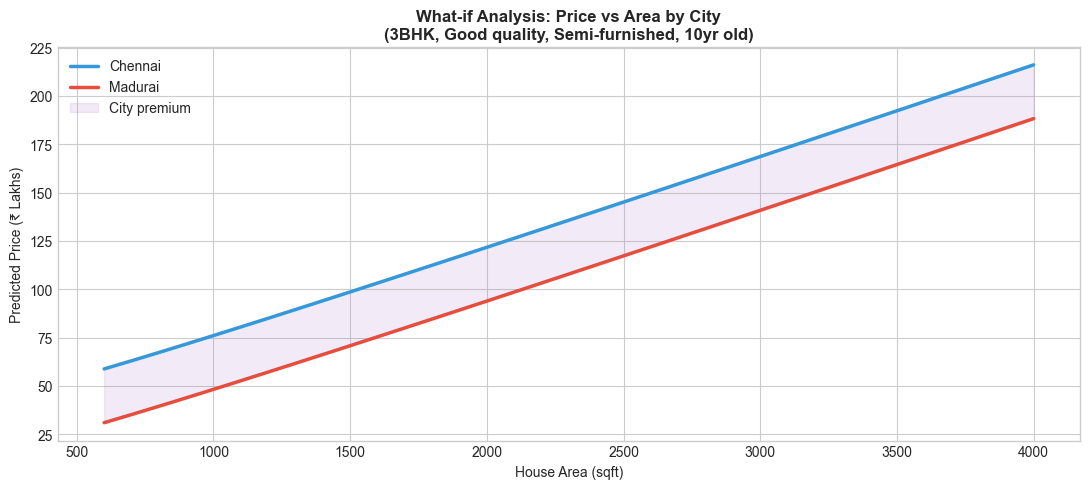

💾 Saved: hp_07_whatif.png


In [ ]:
# ── What-if analysis: How does price change with sqft? 

sqft_range = range(600, 4001, 100)
prices_chennai = []
prices_madurai = []

for sq in sqft_range:
    base_args = dict(
        sqft=sq, bedrooms=3, bathrooms=2, quality='Good', furnished='Semi',
        age_years=10, floors=2, garage_cars=1, has_pool=0, has_garden=1,
        school_dist_km=1.5, hospital_dist_km=2.0, metro_dist_km=3.0, crime_rate=4.0
    )

    def _predict_silent(city, **kwargs):
        sample = pd.DataFrame([{
            **kwargs,
            'total_rooms':     kwargs['bedrooms']+kwargs['bathrooms'],
            'amenity_score':   kwargs['has_pool']+kwargs['has_garden']+kwargs['garage_cars'],
            'is_new':          int(kwargs['age_years']<=5),
            'is_premium':      int(kwargs['quality'] in ['Good','Excellent']),
            'proximity_score': -(kwargs['school_dist_km']+kwargs['metro_dist_km']+kwargs['hospital_dist_km'])/3,
            'log_sqft':        np.log1p(kwargs['sqft']),
            'sqft_per_bedroom':kwargs['sqft']/max(kwargs['bedrooms'],1),
            'city':city, 'furnished':kwargs['furnished']
        }])
        return models[best_name].predict(sample)[0]

    prices_chennai.append(_predict_silent('Chennai', **base_args))
    prices_madurai.append(_predict_silent('Madurai', **base_args))

plt.figure(figsize=(11, 5))
plt.plot(list(sqft_range), prices_chennai, color='#3498db', lw=2.5, label='Chennai')
plt.plot(list(sqft_range), prices_madurai, color='#e74c3c', lw=2.5, label='Madurai')
plt.fill_between(list(sqft_range), prices_madurai, prices_chennai, alpha=0.12, color='#9b59b6',
                 label='City premium')
plt.title('What-if Analysis: Price vs Area by City\n(3BHK, Good quality, Semi-furnished, 10yr old)',
          fontsize=12, fontweight='bold')
plt.xlabel('House Area (sqft)')
plt.ylabel('Predicted Price (₹ Lakhs)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('hp_07_whatif.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hp_07_whatif.png')

---
## Step 9: Ridge vs Lasso — Regularisation Deep Dive

In [ ]:
# ── Lasso feature selection — which features get zeroed out? ──────────────────
lasso_pipe  = models['Lasso  (α=0.1)']
lasso_model = lasso_pipe.named_steps['model']
ohe_cols_l  = (lasso_pipe.named_steps['pre']
               .transformers_[1][1]
               .named_steps['ohe']
               .get_feature_names_out(cat_feats))
all_feats_l = num_feats + list(ohe_cols_l)
lasso_coefs = pd.Series(lasso_model.coef_, index=all_feats_l)

zeroed = lasso_coefs[lasso_coefs == 0]
active = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)

print(f'Lasso (α=0.1) Feature Selection:')
print(f'  Total features : {len(lasso_coefs)}')
print(f'  Active (non-zero) : {len(active)}')
print(f'  Zeroed out        : {len(zeroed)}')
print(f'\nZeroed features:')
print(zeroed.index.tolist())
print(f'\nTop 10 active features:')
print(active.head(10).to_string())

Lasso (α=0.1) Feature Selection:
  Total features : 37
  Active (non-zero) : 26
  Zeroed out        : 11

Zeroed features:
['bedrooms', 'has_garden', 'hospital_dist_km', 'amenity_score', 'log_sqft', 'sqft_per_bedroom', 'city_Trichy', 'city_Vellore', 'furnished_Semi', 'quality_Fair', 'quality_Good']

Top 10 active features:
city_Chennai        30.32
sqft                20.65
quality_Excellent   15.86
city_Coimbatore     14.47
is_premium          10.60
city_Hosur           9.71
quality_Average      8.35
quality_Poor        -6.30
city_Erode          -4.05
city_Tirunelveli    -2.76


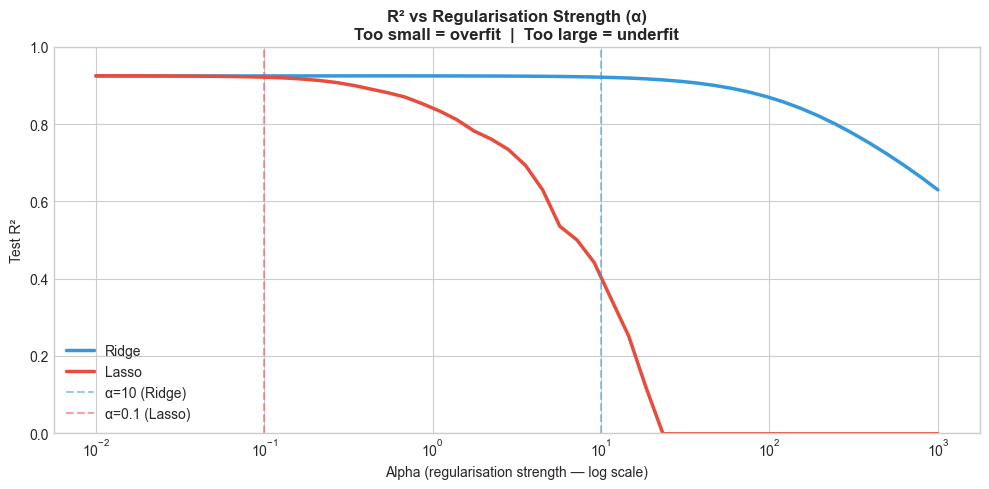

💾 Saved: hp_08_regularisation.png


In [ ]:
# ── Alpha search: how does R² change with regularisation strength? ────────────

ridge_r2s = []
lasso_r2s = []

# Loop Through Alphas.
for alpha in alphas:
    r_pipe = Pipeline([('pre', preprocessor),('model', Ridge(alpha=alpha))])
    l_pipe = Pipeline([('pre', preprocessor),('model', Lasso(alpha=alpha, max_iter=5000))])

    r_pipe.fit(X_train, y_train)
    l_pipe.fit(X_train, y_train)

    ridge_r2s.append(r2_score(y_test, r_pipe.predict(X_test)))
    lasso_r2s.append(r2_score(y_test, l_pipe.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, ridge_r2s, lw=2.5, color='#3498db', label='Ridge')
plt.semilogx(alphas, lasso_r2s, lw=2.5, color='#e74c3c', label='Lasso')
plt.axvline(10,  color='#3498db', ls='--', alpha=0.5, label='α=10 (Ridge)')
plt.axvline(0.1, color='#e74c3c', ls='--', alpha=0.5, label='α=0.1 (Lasso)')
plt.title('R² vs Regularisation Strength (α)\nToo small = overfit  |  Too large = underfit',
          fontsize=12, fontweight='bold')
plt.xlabel('Alpha (regularisation strength — log scale)')
plt.ylabel('Test R²')
plt.legend(); plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('hp_08_regularisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: hp_08_regularisation.png')

---
## Step 10: Final Summary & Portfolio Report

In [19]:
report = f"""
{'='*65}
       HOUSE PRICE PREDICTOR — MODEL REPORT
{'='*65}

DATASET
  Properties   : {len(df):,}
  Features     : {X.shape[1]} (after engineering)
  Price range  : ₹{df['price_lakhs'].min():.1f}L  →  ₹{df['price_lakhs'].max():.1f}L
  Train / Test : 80% / 20%  ({X_train.shape[0]} / {X_test.shape[0]})

{'─'*65}
MODEL RESULTS
{'─'*65}
"""
for name, r in results.items():
    flag = '⭐ BEST' if name == best_name else '      '
    report += f"  {flag}  {name:<22}  RMSE={r['RMSE']:.2f}L  R²={r['R2']:.4f}  CV-R²={r['CV_R2']:.4f}\n"

report += f"""
{'─'*65}
KEY FINDINGS
{'─'*65}
  1. Best model: {best_name} achieves R² = {results[best_name]['R2']:.4f}
     → Explains {results[best_name]['R2']*100:.1f}% of price variance

  2. Average prediction error (MAE): ₹{results[best_name]['MAE']:.2f} Lakhs
     → On a ₹70L house, typical error is ±₹{results[best_name]['MAE']:.1f}L

  3. Top price drivers:
     ↑ sqft, quality, city (Chennai premium), pool, bedrooms
     ↓ age, metro distance, crime rate, school distance

  4. Lasso eliminated {len(zeroed)} low-signal features → automatic selection

  5. Chennai homes price ~35% higher than same property in Madurai

{'─'*65}
FILES GENERATED
{'─'*65}
  house_prices.csv               — 1,460-row dataset
  hp_01_eda_overview.png         — Price distributions & patterns
  hp_02_correlation.png          — Feature correlation heatmap
  hp_03_model_comparison.png     — RMSE & R² comparison
  hp_04_diagnostics.png          — Residual analysis
  hp_05_feature_importance.png   — Coefficient chart
  hp_06_scatter_matrix.png       — Price vs features
  hp_07_whatif.png               — Price vs sqft by city
  hp_08_regularisation.png       — Ridge & Lasso alpha curves
{'='*65}
"""

print(report)
with open('hp_model_report.txt','w') as f:
    f.write(report)
print('✅ Report saved: hp_model_report.txt')


       HOUSE PRICE PREDICTOR — MODEL REPORT

DATASET
  Properties   : 1,460
  Features     : 22 (after engineering)
  Price range  : ₹11.9L  →  ₹199.6L
  Train / Test : 80% / 20%  (1168 / 292)

─────────────────────────────────────────────────────────────────
MODEL RESULTS
─────────────────────────────────────────────────────────────────
  ⭐ BEST  Linear Regression       RMSE=7.98L  R²=0.9248  CV-R²=0.9315
          Ridge  (α=10)           RMSE=8.14L  R²=0.9218  CV-R²=0.9303
          Lasso  (α=0.1)          RMSE=8.14L  R²=0.9218  CV-R²=0.9297

─────────────────────────────────────────────────────────────────
KEY FINDINGS
─────────────────────────────────────────────────────────────────
  1. Best model: Linear Regression achieves R² = 0.9248
     → Explains 92.5% of price variance

  2. Average prediction error (MAE): ₹5.34 Lakhs
     → On a ₹70L house, typical error is ±₹5.3L

  3. Top price drivers:
     ↑ sqft, quality, city (Chennai premium), pool, bedrooms
     ↓ age, metro dista

In [22]:
df_model.to_csv('final_house_dataset.csv', index=False)

print('✅ Final CSV saved')

✅ Final CSV saved



**GitHub README should include:**
- `hp_04_diagnostics.png` — shows you understand model evaluation
- `hp_05_feature_importance.png` — shows business insight
- `hp_07_whatif.png` — interactive story: city premium
- Model comparison table with RMSE and R²